In [1]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
# =========================
# Load dataset splits
# =========================
DATA_PATH = "../../Datasets/Norway Dataset Splits"

X_train = pd.read_csv(f"{DATA_PATH}/X_train.csv")
X_test  = pd.read_csv(f"{DATA_PATH}/X_test.csv")
Y_train = pd.read_csv(f"{DATA_PATH}/Y_train.csv")
Y_test  = pd.read_csv(f"{DATA_PATH}/Y_test.csv")

# Ensure y is 1D
y_train = np.ravel(Y_train)
y_test  = np.ravel(Y_test)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((209, 20789), (52, 20789), (209,), (52,))


Calculating SHAP values...
SHAP values shape: (52, 20789, 5)
Total features: 20789

=== Overall Top 10 Features ===
         Feature  MeanAbsSHAP_MaxAcrossSubtypes
75       MIR1178                       0.004497
16516      THSD4                       0.003357
2237     C1orf59                       0.003280
11948       TNS1                       0.003154
4281        SOX2                       0.003065
11418  RPL13AP20                       0.003027
16574   HIST1H1A                       0.003001
3291   C14orf180                       0.002983
19950      NPHS1                       0.002854
11348    ALDH1L1                       0.002805


C:\Users\Roooiz\AppData\Local\Temp\ipykernel_23288\1018508569.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


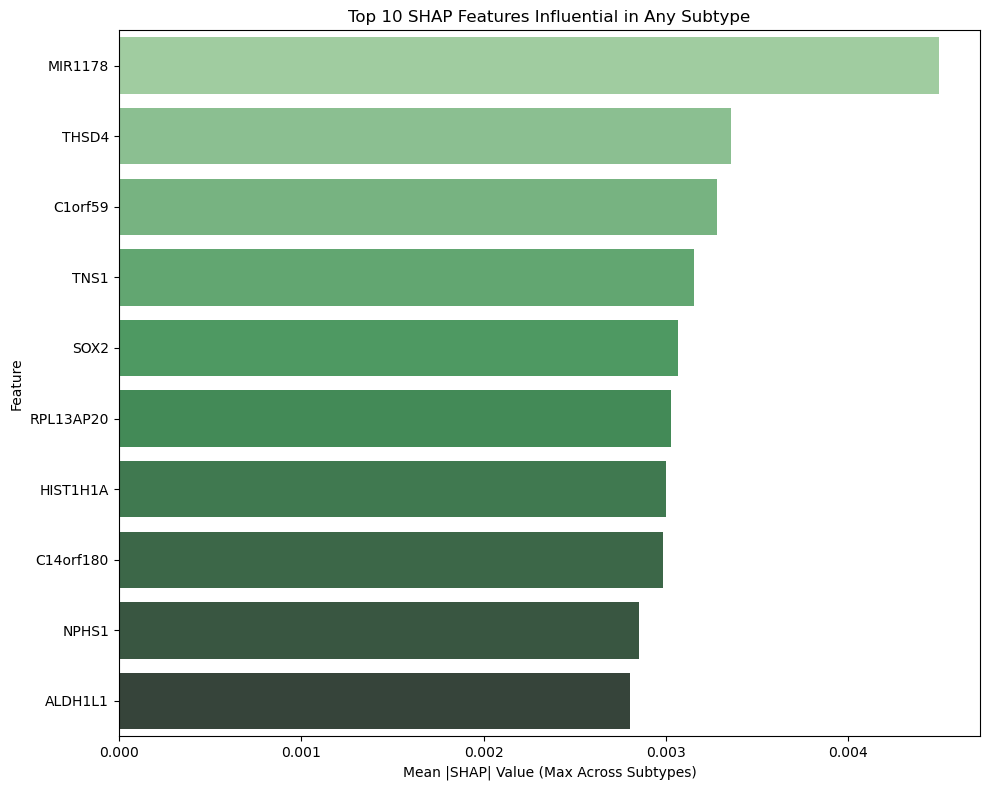

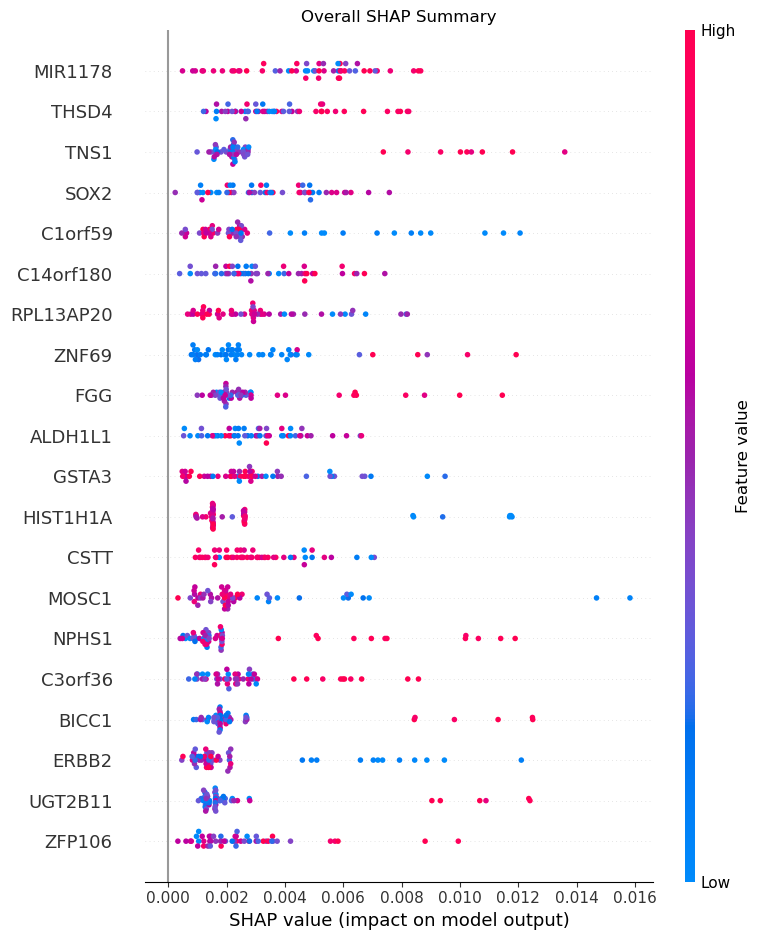


Subtype 1: Basal
        Feature  MeanAbsSHAP
11948      TNS1     0.003072
16574  HIST1H1A     0.003001
5048      BICC1     0.002711
8388        FGG     0.002690
20779   UGT2B11     0.002626
1397    PLEKHG7     0.002236
18856       ZFR     0.002160
9784      TMCC1     0.002116
14377   LGALS9C     0.002066
20113      IAPP     0.002046


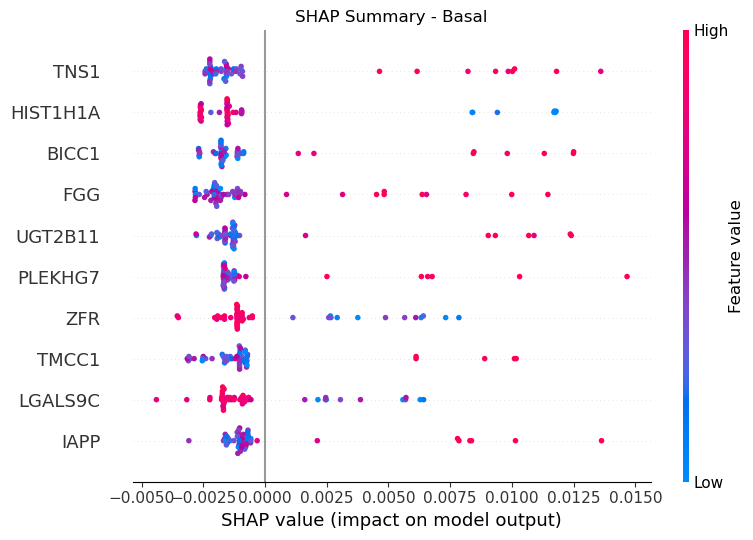

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_23288\1018508569.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


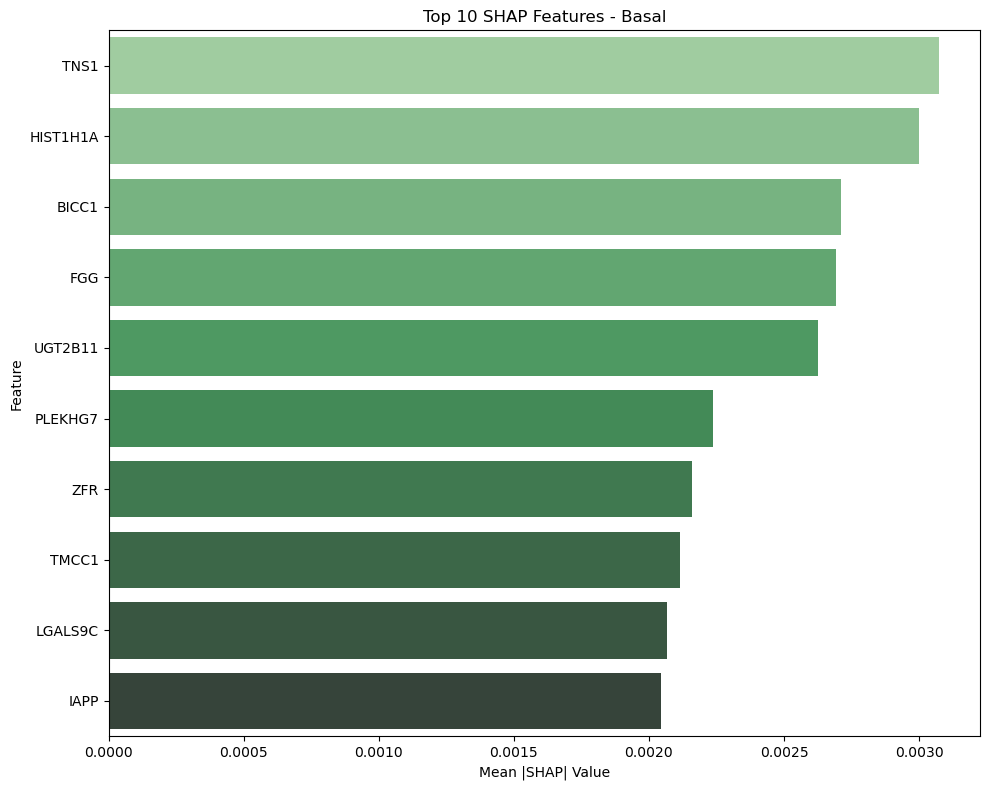


Subtype 2: Her2
        Feature  MeanAbsSHAP
10741     ERBB2     0.002411
75      MIR1178     0.002307
16516     THSD4     0.002221
4281       SOX2     0.002115
7183      ZNF69     0.002106
14903     GSTA3     0.002039
1454    SLC17A9     0.002024
14980     MOSC1     0.001952
2797   TMEM176A     0.001878
13491      FJX1     0.001836


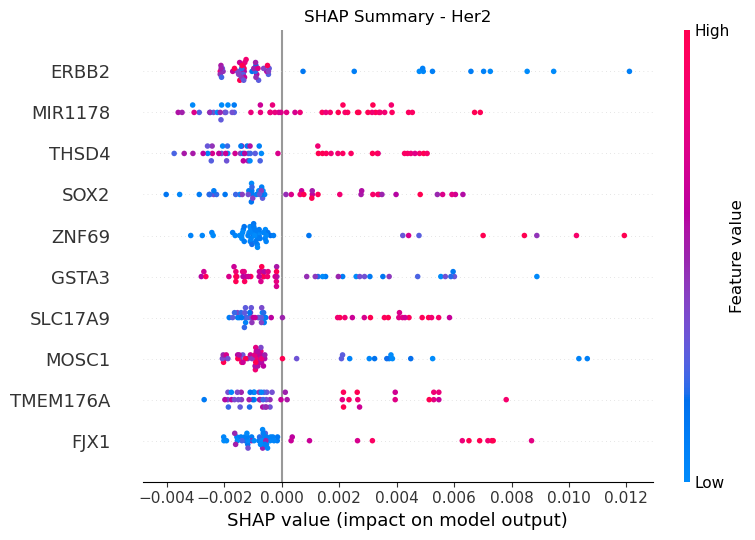

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_23288\1018508569.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


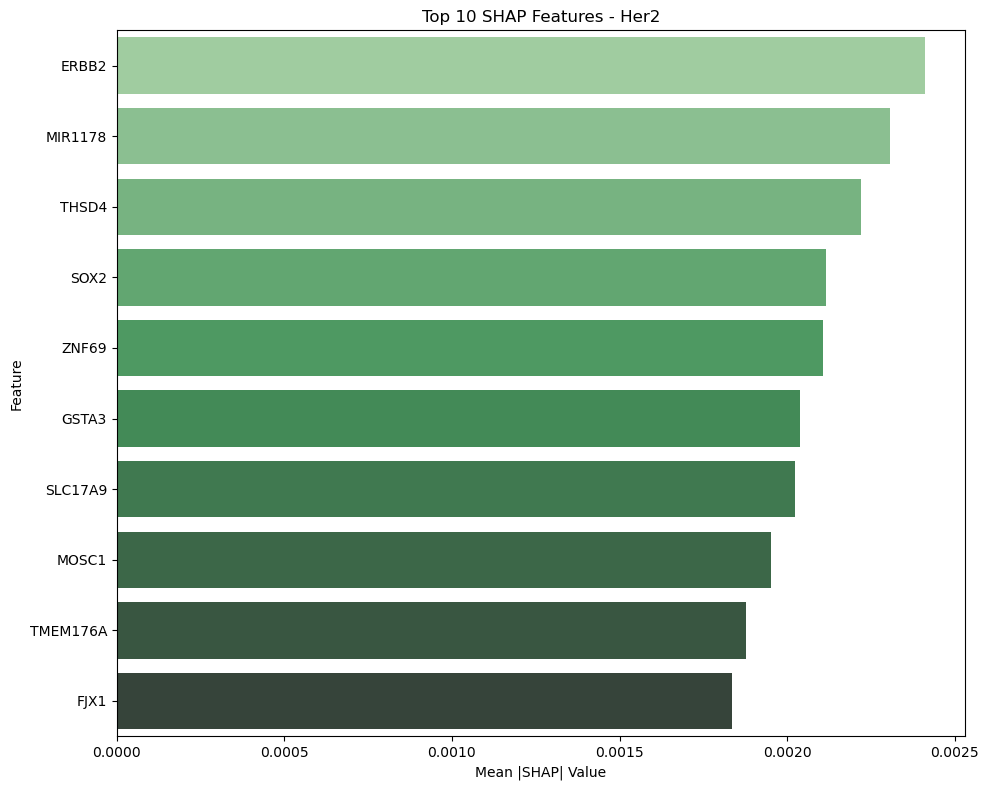


Subtype 3: LumA
         Feature  MeanAbsSHAP
75       MIR1178     0.004497
16516      THSD4     0.003357
2237     C1orf59     0.003280
11948       TNS1     0.003154
4281        SOX2     0.003065
11418  RPL13AP20     0.003027
3291   C14orf180     0.002983
11348    ALDH1L1     0.002805
14980      MOSC1     0.002683
2229        CSTT     0.002626


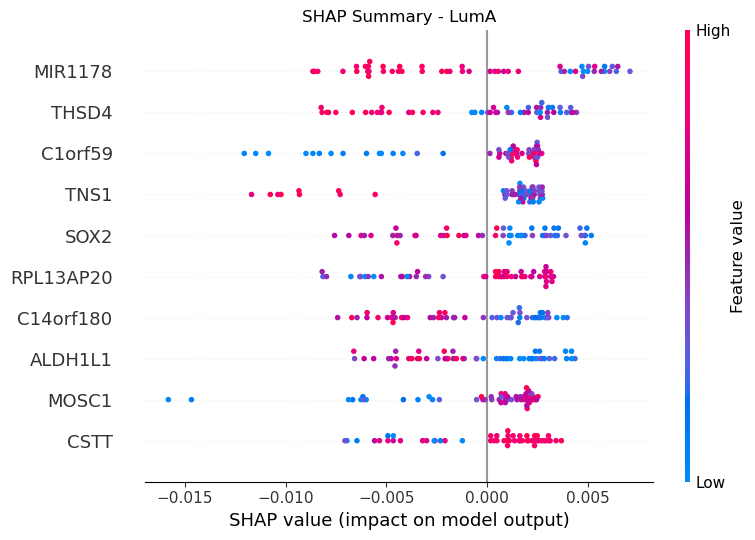

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_23288\1018508569.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


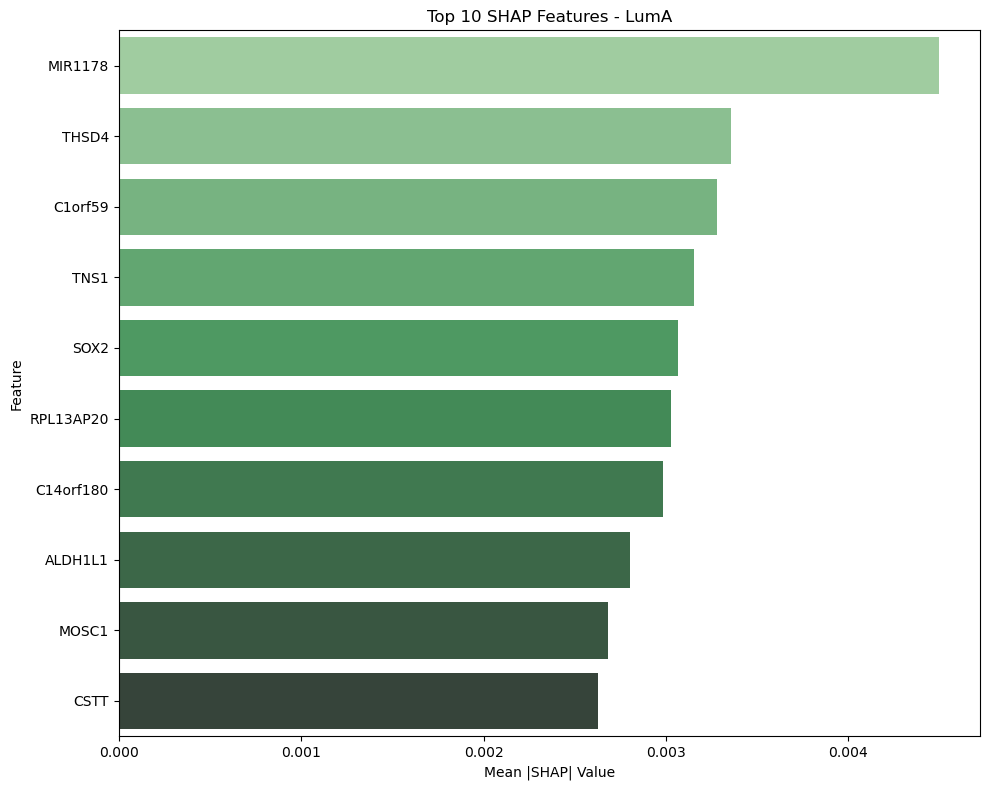


Subtype 4: LumB
         Feature  MeanAbsSHAP
19950      NPHS1     0.002854
17361     ZFP106     0.002320
20522     AQP7P2     0.002037
16527      SNX32     0.001963
75       MIR1178     0.001944
1454     SLC17A9     0.001845
14663     PACRGL     0.001820
267        TRPV1     0.001755
6512     RASGRP3     0.001677
83     LOC121952     0.001674


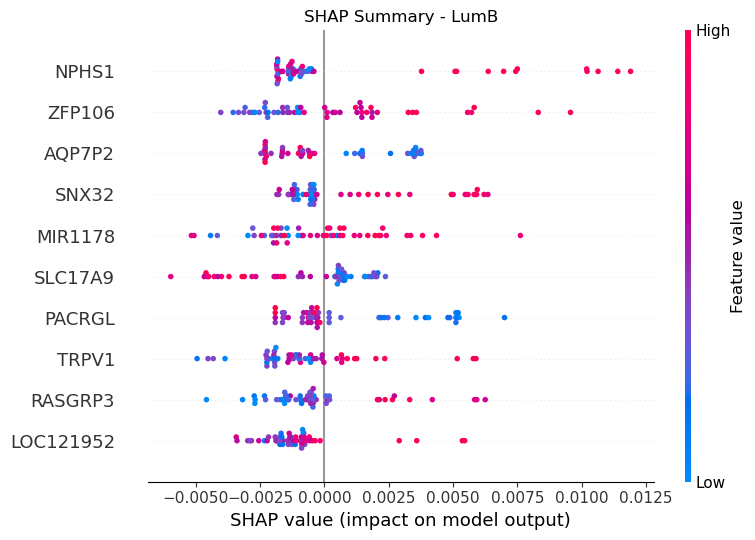

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_23288\1018508569.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


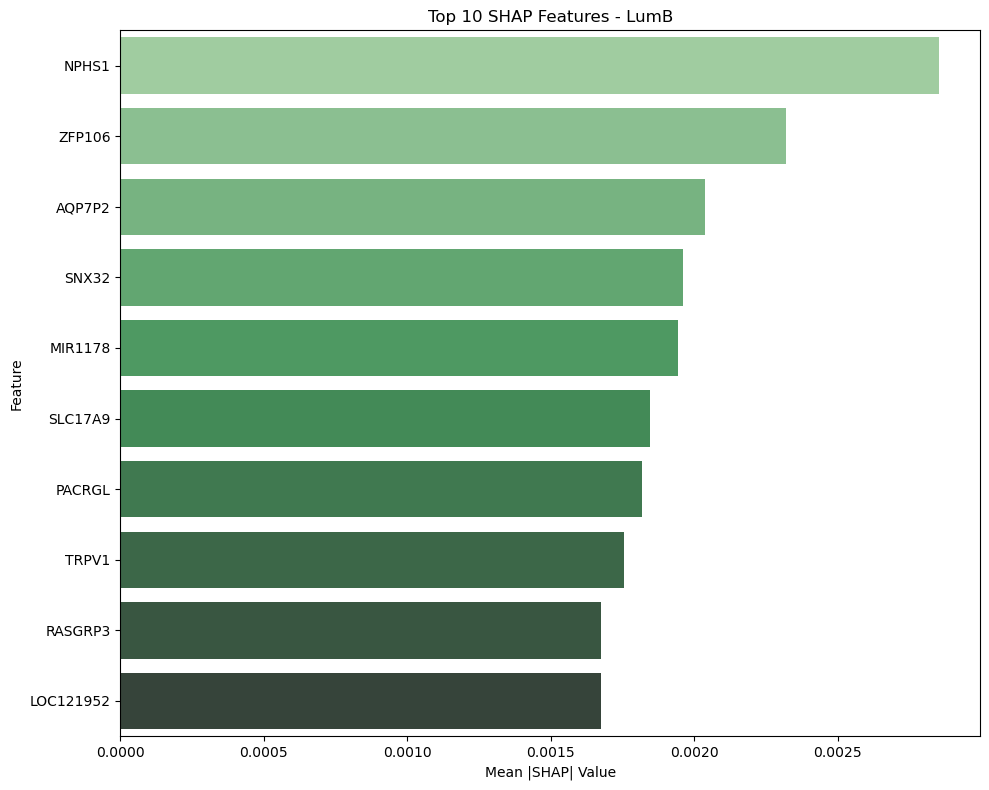


Subtype 5: Normal
         Feature  MeanAbsSHAP
11426       EPN3     0.001394
8388         FGG     0.000987
16907  C10orf131     0.000872
7783      NHEDC2     0.000769
19913      REP15     0.000703
7183       ZNF69     0.000692
7425      PHLPP2     0.000677
19785      ALDOB     0.000656
75       MIR1178     0.000656
11948       TNS1     0.000634


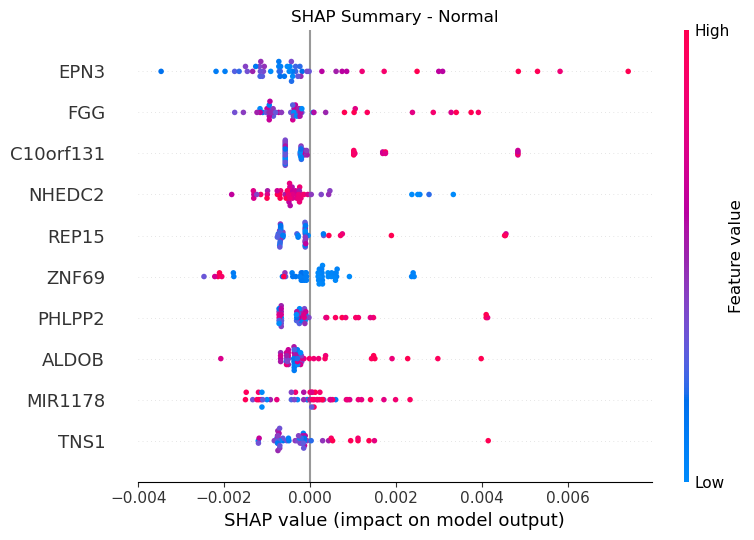

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_23288\1018508569.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


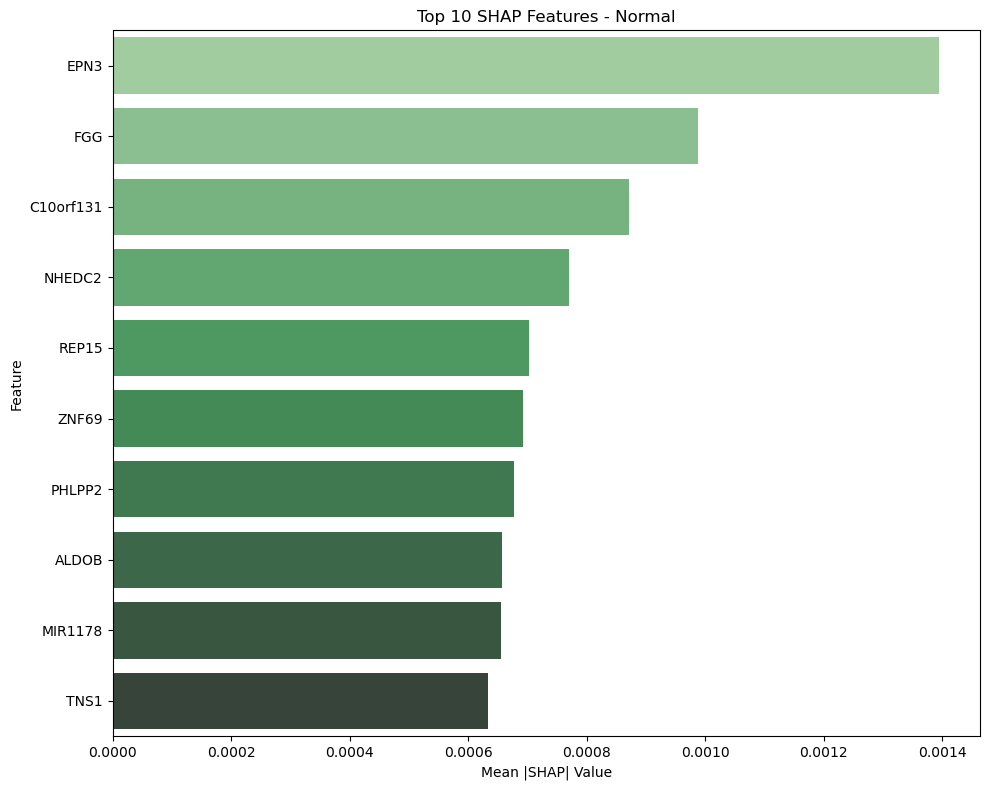


SHAP analysis complete — both overall and per-subtype results generated.


In [6]:
# --- Choose your model ---
best_model_rfe = joblib.load("PKL/RF_Norway_NoImb_No_RFE.pkl")
pipeline_model = best_model_rfe  # or best_model_no_rfe

# --- Extract components ---
rf_model = pipeline_model.named_steps['rf']

# --- Prepare data ---
feature_names = np.array(X_test.columns)

# Scale test set
X_test_input = X_test.values

# --- Create SHAP explainer ---
print("\nCalculating SHAP values...")
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_input)

# Handle multi-class output
if isinstance(shap_values, list):  # one array per class
    shap_values = np.stack(shap_values, axis=2)  # shape: (samples, features, classes)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Total features: {len(feature_names)}")

# ====================================================
# 1. OVERALL (across all classes)
# ====================================================
mean_abs_shap_anywhere = np.abs(shap_values).mean(axis=0).max(axis=1)

shap_importances_overall = pd.DataFrame({
    "Feature": feature_names,
    "MeanAbsSHAP_MaxAcrossSubtypes": mean_abs_shap_anywhere
}).sort_values(by="MeanAbsSHAP_MaxAcrossSubtypes", ascending=False)

print("\n=== Overall Top 10 Features ===")
print(shap_importances_overall.head(10))

# Bar plot
plt.figure(figsize=(10, 8))
sns.barplot(
    data=shap_importances_overall.head(10),
    x="MeanAbsSHAP_MaxAcrossSubtypes",
    y="Feature",
    palette="Greens_d"
)
plt.title("Top 10 SHAP Features Influential in Any Subtype")
plt.xlabel("Mean |SHAP| Value (Max Across Subtypes)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Overall SHAP summary
shap_values_overall = np.abs(shap_values).max(axis=2)  # max per sample across classes
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_overall,
    X_test_input,
    feature_names=feature_names,
    max_display=20,
    show=False
)
plt.title("Overall SHAP Summary")
plt.tight_layout()
plt.show()

# ====================================================
# 2. PER-CLASS (each subtype separately)
# ====================================================
class_names = rf_model.classes_

for class_idx, class_name in enumerate(class_names):
    print(f"\n{'='*50}")
    print(f"Subtype {class_idx + 1}: {class_name}")
    
    shap_values_class = shap_values[:, :, class_idx]
    class_mean_abs_shap = np.abs(shap_values_class).mean(axis=0)
    
    shap_importances_class = pd.DataFrame({
        "Feature": feature_names,
        "MeanAbsSHAP": class_mean_abs_shap
    }).sort_values(by="MeanAbsSHAP", ascending=False)
    
    print(shap_importances_class.head(10))
    
    # SHAP summary plot per class
    plt.figure(figsize=(10, 8))
    shap.summary_plot(
        shap_values_class,
        X_test_input,
        feature_names=feature_names,
        max_display=10,
        show=False
    )
    plt.title(f"SHAP Summary - {class_name}")
    plt.tight_layout()
    plt.show()
    
    # Bar plot top 10 per class
    plt.figure(figsize=(10, 8))
    sns.barplot(
        data=shap_importances_class.head(10),
        x="MeanAbsSHAP",
        y="Feature",
        palette="Greens_d"
    )
    plt.title(f"Top 10 SHAP Features - {class_name}")
    plt.xlabel("Mean |SHAP| Value")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

print("\nSHAP analysis complete — both overall and per-subtype results generated.")